In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [2]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

El coeficiente de correlación de Pearson es: -0.3293


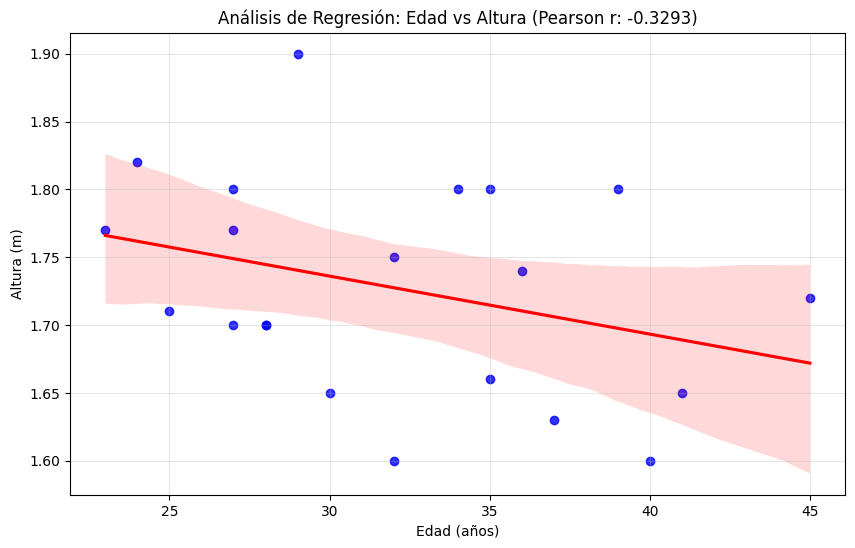

In [5]:
df = pd.DataFrame(lista_alumnos, columns=['Nombre', 'Edad', 'Altura'])

# Calcular la correlación de Pearson con Pandas
correlacion = df['Edad'].corr(df['Altura'])

# Crear el gráfico con Seaborn
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Edad', y='Altura', scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})

# Personalización
plt.title(f'Análisis de Regresión: Edad vs Altura (Pearson r: {correlacion:.4f})')
plt.xlabel('Edad (años)')
plt.ylabel('Altura (m)')
plt.grid(True, alpha=0.3)

print(f"El coeficiente de correlación de Pearson es: {correlacion:.4f}")
plt.show()

### Entrena un modelo de regresión lineal

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

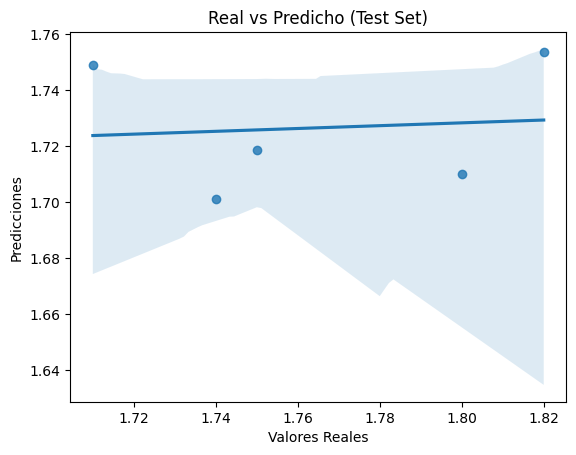

In [7]:
X = df[['Edad']]
y = df['Altura']

# División y Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# Visualización opcional para confirmar el modelo
sns.regplot(x=y_test, y=y_pred)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicho (Test Set)')
plt.show()

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [8]:
# 1. Creamos un DataFrame para comparar los valores reales vs predichos
df_errores = pd.DataFrame({
    'Valor Real (y_test)': y_test.values,
    'Predicción (y_pred)': y_pred,
    'Error Absoluto (m)': abs(y_test.values - y_pred)
})

# 2. Calculamos el error porcentual por cada fila
df_errores['Error (%)'] = (df_errores['Error Absoluto (m)'] / df_errores['Valor Real (y_test)']) * 100

# 3. Mostramos el desglose
print("Desglose de errores por predicción:")
print(df_errores)

# 4. Cálculo de los promedios (Métricas que ya obtuviste)
print(f"\nResumen de errores promedio:")
print(f"Error medio en centímetros: {df_errores['Error Absoluto (m)'].mean() * 100:.2f} cm")
print(f"Error porcentual medio: {df_errores['Error (%)'].mean():.2f}%")

Desglose de errores por predicción:
   Valor Real (y_test)  Predicción (y_pred)  Error Absoluto (m)  Error (%)
0                 1.82             1.753478            0.066522   3.655041
1                 1.80             1.709906            0.090094   5.005213
2                 1.75             1.718621            0.031379   1.793110
3                 1.71             1.749121            0.039121   2.287781
4                 1.74             1.701192            0.038808   2.230360

Resumen de errores promedio:
Error medio en centímetros: 5.32 cm
Error porcentual medio: 2.99%


In [9]:
# 4. Cálculo manual de métricas (usando operaciones de Series de Pandas/Numpy)
# Diferencia entre real y predicción
errores = y_test - y_pred

mae = errores.abs().mean()
mse = (errores**2).mean()
rmse = mse**(0.5)
mape = (errores.abs() / y_test).mean()

# 5. Resultados
print(f"Métricas de Error calculadas manualmente:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4%}")

Métricas de Error calculadas manualmente:
MAE:  0.0532
MSE:  0.0033
RMSE: 0.0576
MAPE: 2.9943%
